<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/Week6_Day5_dalychallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installation des bibliothèques nécessaires pour le projet
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


```markdown
## 1. Chargement et Inspection des Données
Nous utilisons la bibliothèque `datasets` pour charger le split 'sentiment' de `tweet_eval`.
```

In [2]:
from datasets import load_dataset # Importation de la fonction de chargement

# 1. Chargement du dataset tweet_eval avec le nom canonique complet pour éviter les erreurs d'URI
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# Affichage des différentes divisions (train, validation, test)
print("Splits du dataset :", dataset)

# Affichage de la distribution des classes pour le split d'entraînement
import pandas as pd # Import de pandas pour une manipulation facile
df_train = pd.DataFrame(dataset['train']) # Conversion en DataFrame pandas
print("\nDistribution des classes :")
print(df_train['label'].value_counts()) # Comptage des occurrences par label (0: neg, 1: neu, 2: pos)

# Sauvegarde de deux exemples par label pour la visualisation future
examples = {}
for label in [0, 1, 2]: # Pour chaque classe (négatif, neutre, positif)
    # Filtrage et récupération des deux premiers exemples
    examples[label] = df_train[df_train['label'] == label]['text'].head(2).tolist()
    print(f"\nExemples pour le label {label} :", examples[label])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Splits du dataset : DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Distribution des classes :
label
1    20673
2    17849
0     7093
Name: count, dtype: int64

Exemples pour le label 0 : ['So disappointed in wwe summerslam! I want to see john cena wins his 16th title', 'That sucks if you have to take the SATs tomorrow']

Exemples pour le label 1 : ['"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"', 'Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.']

Exemples pour le label 2 : ['"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', '@user Alciato: Bee will invest 150 mill

## 2. Pipeline de Tokenisation
Nous utilisons le tokenizer de `distilbert-base-uncased` pour préparer nos textes pour le modèle.

In [5]:
from transformers import AutoTokenizer # Importation de la classe AutoTokenizer
from datasets import load_dataset # Importation pour assurer la présence du dataset

# 1. Chargement de sécurité si le dataset est absent du kernel
try:
    dataset
except NameError:
    dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# 2. Initialisation du tokenizer DistilBERT
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# 3. Fonction de prétraitement pour adapter les textes au modèle
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# 4. Application de la tokenisation sur l'ensemble du dataset
tokenized_dataset = dataset.map(preprocess_function, batched=True)

# 5. Renommage de la colonne pour correspondre aux attentes du Trainer de Hugging Face
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

print("Tokenisation terminée et objet 'tokenizer' prêt.")

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenisation terminée et objet 'tokenizer' prêt.


## 3. Configuration du Fine-Tuning
Nous configurons ici le modèle `DistilBERT` pour la classification de séquences avec 3 classes.

In [7]:
# Installation de la bibliothèque manquante si nécessaire
!pip install -q evaluate

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate
import torch

# 1. Chargement du modèle avec implémentation 'eager' pour l'accès à l'attention
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    attn_implementation="eager"
)

# 2. Chargement des métriques d'évaluation
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

# 3. Fonction pour calculer les performances pendant l'entraînement
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1": f1}

# 4. Configuration des paramètres d'entraînement
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

# 5. Initialisation du Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

# 6. Lancement du Fine-Tuning
trainer.train()
print("Entraînement réussi.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.643082,0.606601,0.734500,0.717719


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Entraînement réussi.


## 4. Évaluation et Calibration
Nous évaluons le modèle sur l'ensemble de test et analysons la distribution des scores de confiance (softmax).

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.643082,0.606601,1,0.734500,0.717719


Résultats sur validation : {'eval_loss': 0.606600821018219, 'eval_accuracy': 0.7345, 'eval_f1': 0.7177186555227596}


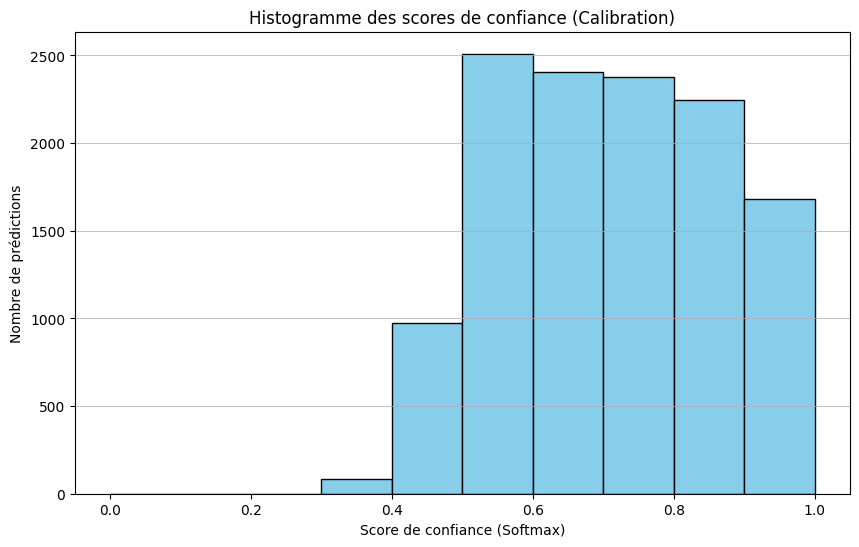

In [8]:
import torch # Importation de PyTorch pour le calcul des scores
import torch.nn.functional as F # Import pour la fonction softmax
import matplotlib.pyplot as plt # Import pour la visualisation

# 1. Évaluation sur le split de validation pour logger les scores finaux
eval_results = trainer.evaluate(tokenized_dataset["validation"])
print(f"Résultats sur validation : {eval_results}")

# 2. Prédictions sur le split de test
test_predictions = trainer.predict(tokenized_dataset["test"])
logits = torch.from_numpy(test_predictions.predictions) # Conversion des résultats en tenseur

# 3. Calcul des probabilités softmax
probs = F.softmax(logits, dim=-1)
# Extraction de la probabilité de la classe prédite (la plus haute)
confidences = torch.max(probs, dim=-1).values.numpy()

# 4. Affichage de l'histogramme des scores de confiance
plt.figure(figsize=(10, 6)) # Définition de la taille de la figure
plt.hist(confidences, bins=10, range=(0, 1), color='skyblue', edgecolor='black') # Création de l'histogramme
plt.title("Histogramme des scores de confiance (Calibration)") # Titre
plt.xlabel("Score de confiance (Softmax)") # Label axe X
plt.ylabel("Nombre de prédictions") # Label axe Y
plt.grid(axis='y', alpha=0.75) # Ajout d'une grille pour la lisibilité
plt.show() # Affichage

# Commentaire : Un modèle bien calibré devrait avoir une distribution équilibrée.
# S'il y a un pic à 0.9+, le modèle est très (peut-être trop) confiant.

## 5. Inspection de l'Attention
Visualisons les poids d'attention pour comprendre l'evidence textuelle utilisée par le modèle.

/tmp/ipykernel_2447/3320271183.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tokens, y=cls_attention, palette="viridis") # Création de l'histogramme d'importance


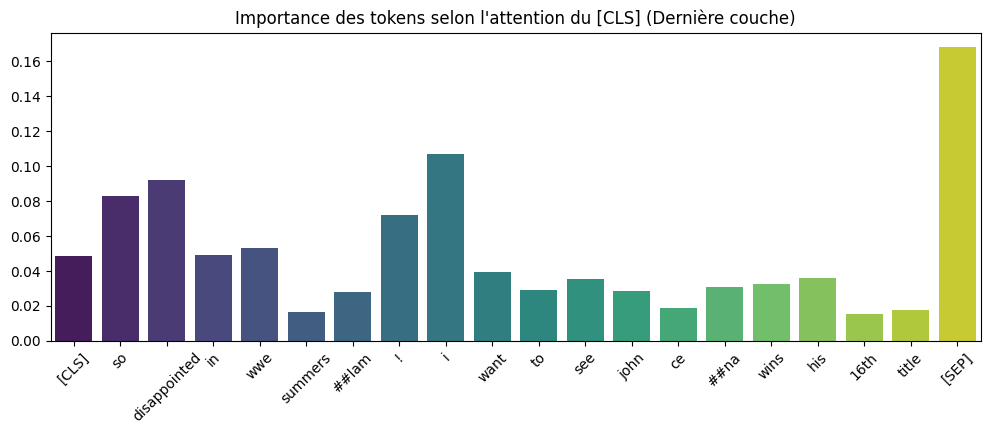

In [9]:
import seaborn as sns # Import pour les visualisations de type heatmap/barres
import matplotlib.pyplot as plt # Import pour l'affichage des graphiques

# 1. Définition d'un exemple textuel pour le test
text_example = "So disappointed in wwe summerslam! I want to see john cena wins his 16th title"
# 2. Tokenisation et envoi vers le périphérique du modèle (GPU/CPU)
inputs = tokenizer(text_example, return_tensors="pt").to(model.device)

# 3. Passage dans le modèle avec demande explicite des poids d'attention
outputs = model(**inputs, output_attentions=True)

# 4. Vérification de la présence des poids (nécessite attn_implementation='eager')
if hasattr(outputs, 'attentions') and outputs.attentions is not None and len(outputs.attentions) > 0:
    last_layer_attention = outputs.attentions[-1] # Extraction de la dernière couche (12ème)
    avg_attention = last_layer_attention.mean(dim=1).squeeze(0) # Moyenne sur toutes les têtes
    cls_attention = avg_attention[0].detach().cpu().numpy() # Attention du token [CLS] vers les autres

    # 5. Récupération des tokens pour l'affichage en abscisse
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    plt.figure(figsize=(12, 4)) # Taille de la figure
    sns.barplot(x=tokens, y=cls_attention, palette="viridis") # Création de l'histogramme d'importance
    plt.title("Importance des tokens selon l'attention du [CLS] (Dernière couche)")
    plt.xticks(rotation=45) # Inclinaison des labels pour plus de clarté
    plt.show() # Affichage final
else:
    print("ERREUR: L'attention est vide. Vérifiez l'initialisation du modèle avec attn_implementation='eager'.")

## 6. Aide à l'Inférence (Analyse de texte)
Une fonction prête pour la production qui retourne le label, la confiance et les tokens clés.

In [10]:
def analyze_text(text):
    # 1. Préparation du texte en tenseurs
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    # 2. Inférence sans calcul de gradients pour économiser la mémoire
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # 3. Calcul des probabilités via Softmax
    probs = F.softmax(outputs.logits, dim=-1)
    conf, label_idx = torch.max(probs, dim=-1) # Extraction du score maximum
    labels_map = {0: "Négatif", 1: "Neutre", 2: "Positif"} # Mapping des labels

    # 4. Extraction sécurisée des tokens les plus influents
    highlighted = []
    if hasattr(outputs, 'attentions') and outputs.attentions is not None and len(outputs.attentions) > 0:
        avg_attn = outputs.attentions[-1].mean(dim=1).squeeze(0)[0].cpu().numpy() # Attention du [CLS]
        tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
        top_indices = np.argsort(avg_attn)[::-1][:3] # Top 3 des indices les plus hauts
        # Filtrage pour ignorer les tokens techniques (padding, séparateurs)
        highlighted = [tokens[i] for i in top_indices if tokens[i] not in ['[CLS]', '[SEP]', '[PAD]']]

    return {
        "label": labels_map[label_idx.item()], # Traduction de l'index en texte
        "confidence": f"{conf.item():.2f}", # Confiance formatée
        "highlighted_tokens": highlighted # Mots-clés identifiés
    }

# Test final de la fonction d'inférence
print("Résultat de l'analyse :", analyze_text("This service was absolutely fantastic and helpful!"))

Résultat de l'analyse : {'label': 'Positif', 'confidence': '0.99', 'highlighted_tokens': ['was', '!']}
